# Research Question 3: Orthogonal Defect Classification (ODC) Analysis

**Research Question:**
To what extent do the distributions of specific code defect types differ between AI-generated and human-generated commits when mapped to the Orthogonal Defect Classification (ODC), and are these differences explained by Cognitive Load Theory versus the Probabilistic Logic of LLMs?

**Core Hypotheses:**
1. ODC type distributions differ between AI and Human commits
2. Cognitive load (intrinsic/extraneous/germane) explains ODC differences
3. LLM-specific error patterns (off-by-one, API hallucination, etc.) are more prevalent in AI commits
4. Domain type moderates the AI/Human ODC differences
5. Code complexity (measured via cognitive load) explains defect type distribution

## Section 1: Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load RQ3 Data

In [2]:
# Load RQ3 defect classifier frame (commit-level)
df = pd.read_parquet('../results/rq3_defect_classifier_frame.parquet')
print(f"Loaded {len(df):,} classified commits (commit-level granularity)")
print(f"Shape: {df.shape}")
print(f"\nColumns in dataset:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

# Quick validation
print(f"\n" + "="*60)
print("FIRST LOOK AT DATA")
print("="*60)
df.head()

Loaded 2,044 classified commits (commit-level granularity)
Shape: (2044, 30)

Columns in dataset:
['id', 'sha', 'ai_pr', 'number', 'user', 'repo_full_name', 'domain_type_group', 'task_type_group', 'created_at', 'pr_size_loc', 'intrinsic_load', 'extraneous_load', 'germane_load', 'total_cognitive_load', 'clt_category', 'overload_risk', 'llm_error_likelihood', 'off_by_one_risk', 'api_hallucination_risk', 'naming_inconsistency_risk', 'missing_error_handling_risk', 'copy_paste_error_risk', 'odc_type', 'odc_type_name', 'odc_class', 'odc_class_name', 'odc_trigger', 'odc_trigger_name', 'odc_impact', 'odc_impact_name']

Data types:
id                                           int64
sha                                         object
ai_pr                                        int64
number                                       int64
user                                        object
repo_full_name                              object
domain_type_group                            int64
task_type_gr

,id,sha,ai_pr,number,user,repo_full_name,domain_type_group,task_type_group,created_at,pr_size_loc,intrinsic_load,extraneous_load,germane_load,total_cognitive_load,clt_category,overload_risk,llm_error_likelihood,off_by_one_risk,api_hallucination_risk,naming_inconsistency_risk,missing_error_handling_risk,copy_paste_error_risk,odc_type,odc_type_name,odc_class,odc_class_name,odc_trigger,odc_trigger_name,odc_impact,odc_impact_name
0,2256777953,b67ae10281659b2ece4e816c59460b89585745a0,0,16091,Jarred-Sumner,oven-sh/bun,4,NaN,2025-01-01 00:43:38+00:00,2.0,1.200000,1.000000,1.200000,2.200000,1.0,0.0,0.256667,0.0,0.7,0.233333,0.0,0.000000,8,BUILD_INTEGRATION,0,FUNCTION,0,CODE_REVIEW,3,MINOR
1,2256824367,d20c3f234a1c571de8800d72dbbdaab8d712f544,0,16093,dylan-conway,oven-sh/bun,4,0.0,2025-01-01 03:08:38+00:00,624.0,1.200000,1.600000,0.960000,2.800000,1.0,0.0,0.308750,0.0,1.0,0.043750,0.0,0.000000,0,API_MISUSE,3,BUILD_INTEGRATION,0,CODE_REVIEW,1,MAJOR
2,2256824367,413c700b5764c8ac33cfaaaf679a54f17917b012,0,16093,dylan-conway,oven-sh/bun,4,0.0,2025-01-01 03:08:38+00:00,624.0,1.200000,1.000000,1.200000,2.200000,1.0,0.0,0.256667,0.0,0.7,0.233333,0.0,0.000000,8,BUILD_INTEGRATION,3,BUILD_INTEGRATION,0,CODE_REVIEW,3,MINOR
3,2256824367,c5c7b4b02bf8d5d8c5001f4036379ed6e9583c0b,0,16093,dylan-conway,oven-sh/bun,4,0.0,2025-01-01 03:08:38+00:00,624.0,1.000000,1.112500,1.000000,2.112500,1.0,0.0,0.009333,0.0,0.0,0.046667,0.0,0.000000,8,BUILD_INTEGRATION,3,BUILD_INTEGRATION,0,CODE_REVIEW,3,MINOR
4,2256824367,2bc95bb724ee372d23d12c92a957d265bb3ff39b,0,16093,dylan-conway,oven-sh/bun,4,0.0,2025-01-01 03:08:38+00:00,624.0,1.667043,0.069588,1.646713,1.736631,0.0,0.0,0.364386,0.0,1.0,0.000000,0.0,0.429239,0,API_MISUSE,3,BUILD_INTEGRATION,0,CODE_REVIEW,3,MINOR


## Section 3: Data Validation & Overview

In [3]:
# Basic statistics
print("AI vs Human Split:")
ai_count = (df['ai_pr'] == 1).sum()
human_count = (df['ai_pr'] == 0).sum()
print(f"  AI:    {ai_count:,} ({ai_count/len(df)*100:.1f}%)")
print(f"  Human: {human_count:,} ({human_count/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("Missing Values by Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing[missing > 0], 'Percentage': missing_pct[missing > 0]})
print(missing_df.sort_values('Count', ascending=False))

print("\n" + "="*60)
print("ODC Type Distribution (Overall):")
print(df['odc_type_name'].value_counts().sort_values(ascending=False))

print("\n" + "="*60)
print("ODC Impact Distribution (Overall):")
print(df['odc_impact_name'].value_counts().sort_values(ascending=False))

print("\n" + "="*60)
print("Domain Distribution:")
print(df['domain_type_group'].value_counts().sort_index())

print("\n" + "="*60)
print("Cognitive Load Category Distribution:")
clt_names = {0: 'LOW', 1: 'MODERATE', 2: 'HIGH', 3: 'VERY_HIGH'}
for cat, name in clt_names.items():
    count = (df['clt_category'] == cat).sum()
    pct = count / len(df) * 100
    print(f"  {name}: {count:,} ({pct:.1f}%)")

AI vs Human Split:
  AI:    1,100 (53.8%)
  Human: 944 (46.2%)

Missing Values by Column:
                 Count  Percentage
task_type_group    139         6.8

ODC Type Distribution (Overall):
odc_type_name
LOGIC                769
API_MISUSE           621
BUILD_INTEGRATION    269
INTERFACE            214
DATA                 104
DOCUMENTATION         32
ASSIGNMENT            14
TIMING                12
CHECKING               9
Name: count, dtype: int64

ODC Impact Distribution (Overall):
odc_impact_name
MINOR       1329
MAJOR        414
MODERATE     291
CRITICAL      10
Name: count, dtype: int64

Domain Distribution:
domain_type_group
0     507
1     435
2      44
3      35
4    1023
Name: count, dtype: int64

Cognitive Load Category Distribution:
  LOW: 116 (5.7%)
  MODERATE: 1,869 (91.4%)
  HIGH: 43 (2.1%)
  VERY_HIGH: 16 (0.8%)


## Section 4: Overall ODC Distribution (AI vs Human)

In [4]:
# Cross-tabulation: ODC Type by AI/Human
odc_by_ai = pd.crosstab(df['ai_pr'], df['odc_type_name'], margins=True)
print("ODC Type by AI/Human (Counts):")
print(odc_by_ai)

# Normalized by row (percentages)
odc_by_ai_norm = pd.crosstab(df['ai_pr'], df['odc_type_name'], normalize='index') * 100
print("\nODC Type by AI/Human (Row Percentages):")
print(odc_by_ai_norm.round(1))

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['ai_pr'], df['odc_type_name'])
chi2, p_val, dof, expected = chi2_contingency(contingency)

# Effect size (Cramér's V)
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print("\n" + "="*60)
print("H1: ODC TYPE DISTRIBUTION DIFFERS (AI vs Human)")
print("="*60)
print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Effect size (Cramér's V): {cramers_v:.4f}")
print(f"Result: {'✓ SUPPORTED (p < 0.05)' if p_val < 0.05 else '✗ NOT SUPPORTED (p >= 0.05)'}")

ODC Type by AI/Human (Counts):
odc_type_name  API_MISUSE  ASSIGNMENT  BUILD_INTEGRATION  CHECKING  DATA  \
ai_pr                                                                      
0                     349           7                112         5    49   
1                     272           7                157         4    55   
All                   621          14                269         9   104   

odc_type_name  DOCUMENTATION  INTERFACE  LOGIC  TIMING   All  
ai_pr                                                         
0                         18         93    303       8   944  
1                         14        121    466       4  1100  
All                       32        214    769      12  2044  

ODC Type by AI/Human (Row Percentages):
odc_type_name  API_MISUSE  ASSIGNMENT  BUILD_INTEGRATION  CHECKING  DATA  \
ai_pr                                                                      
0                    37.0         0.7               11.9       0.5   5.2   
1   

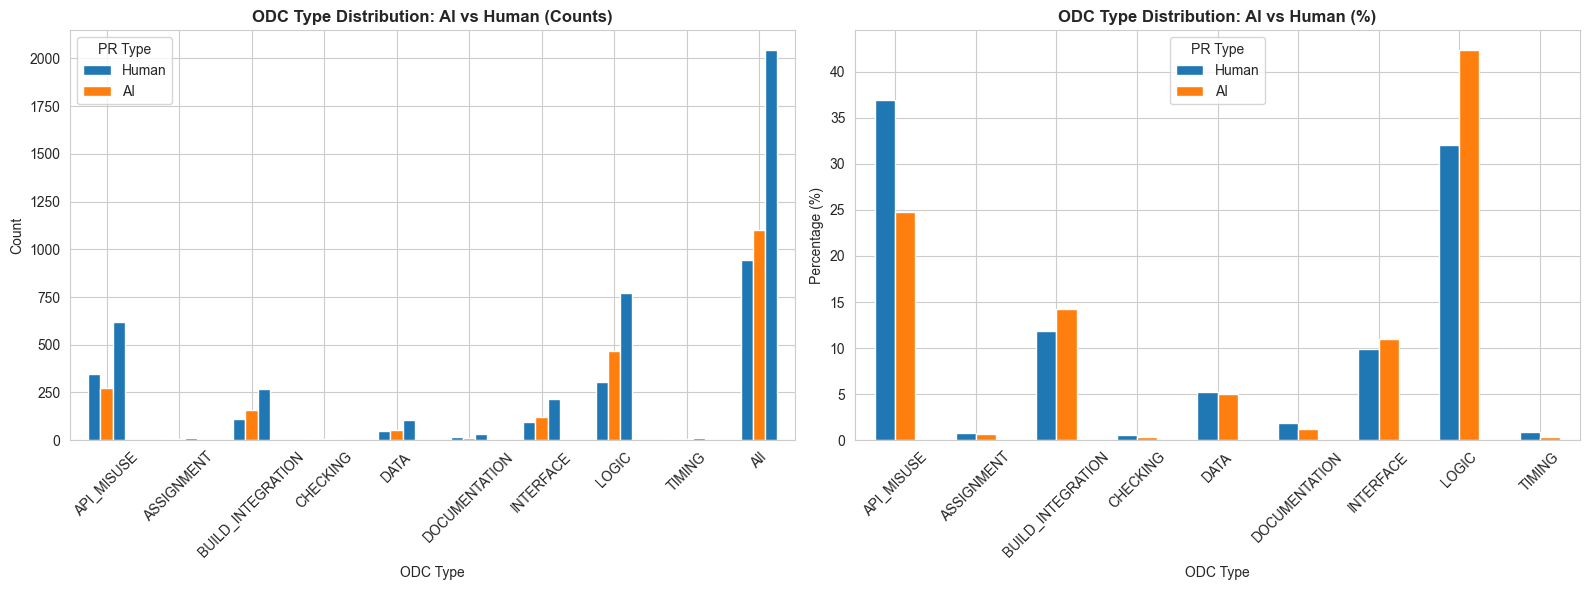

In [5]:
# Visualize ODC type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts
odc_by_ai.T.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('ODC Type Distribution: AI vs Human (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ODC Type')
axes[0].set_ylabel('Count')
axes[0].legend(['Human', 'AI'], title='PR Type')
axes[0].tick_params(axis='x', rotation=45)

# Percentages
odc_by_ai_pct = pd.crosstab(df['ai_pr'], df['odc_type_name'], normalize='index') * 100
odc_by_ai_pct.T.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('ODC Type Distribution: AI vs Human (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ODC Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Human', 'AI'], title='PR Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/rq3_odc_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 5: Chi-Square Tests for ODC Distributions

In [6]:
from scipy.stats import chi2_contingency

# Hypothesis 1: ODC type distribution differs between AI and Human
#contingency_type = pd.crosstab(df['ai_pr'], df['odc_type_group'])
print(df.shape)
print(df.columns.tolist())

contingency_type = pd.crosstab(df['ai_pr'], df['odc_type_name'])
chi2, p_val, dof, expected = chi2_contingency(contingency_type)

print("="*70)
print("HYPOTHESIS 1: ODC Type Distribution Differs by AI/Human")
print("="*70)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'SUPPORTED (p < 0.05)' if p_val < 0.05 else 'NOT SUPPORTED (p >= 0.05)'}")

# Cramér's V for effect size
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency_type.shape) - 1)))
print(f"Cramér's V (effect size): {cramers_v:.4f}")

(2044, 30)
['id', 'sha', 'ai_pr', 'number', 'user', 'repo_full_name', 'domain_type_group', 'task_type_group', 'created_at', 'pr_size_loc', 'intrinsic_load', 'extraneous_load', 'germane_load', 'total_cognitive_load', 'clt_category', 'overload_risk', 'llm_error_likelihood', 'off_by_one_risk', 'api_hallucination_risk', 'naming_inconsistency_risk', 'missing_error_handling_risk', 'copy_paste_error_risk', 'odc_type', 'odc_type_name', 'odc_class', 'odc_class_name', 'odc_trigger', 'odc_trigger_name', 'odc_impact', 'odc_impact_name']
HYPOTHESIS 1: ODC Type Distribution Differs by AI/Human
Chi-square statistic: 45.9411
P-value: 0.000000
Degrees of freedom: 8

Result: SUPPORTED (p < 0.05)
Cramér's V (effect size): 0.1499


In [7]:
# Hypothesis 2: ODC Impact distribution differs
contingency_impact = pd.crosstab(df['ai_pr'], df['odc_impact_name'])
chi2_imp, p_val_imp, dof_imp, _ = chi2_contingency(contingency_impact)

print("\n" + "="*70)
print("HYPOTHESIS 2: ODC Impact Distribution Differs by AI/Human")
print("="*70)
print(f"Chi-square statistic: {chi2_imp:.4f}")
print(f"P-value: {p_val_imp:.6f}")
print(f"Result: {'SUPPORTED (p < 0.05)' if p_val_imp < 0.05 else 'NOT SUPPORTED (p >= 0.05)'}")


HYPOTHESIS 2: ODC Impact Distribution Differs by AI/Human
Chi-square statistic: 34.3730
P-value: 0.000000
Result: SUPPORTED (p < 0.05)


## Section 6: Cognitive Load Theory Analysis - Does CLT Explain ODC Differences?

In [8]:
print("\n" + "="*70)
print("H2: COGNITIVE LOAD DIFFERENCES (AI vs Human)")
print("="*70)

# Cognitive load metrics
ai_clt = df[df['ai_pr'] == 1]['total_cognitive_load'].dropna()
human_clt = df[df['ai_pr'] == 0]['total_cognitive_load'].dropna()

t_stat_clt, p_val_clt = stats.ttest_ind(ai_clt, human_clt)
cohens_d_clt = (ai_clt.mean() - human_clt.mean()) / np.sqrt((ai_clt.std()**2 + human_clt.std()**2) / 2)

print(f"\nTotal Cognitive Load:")
print(f"  AI:    Mean={ai_clt.mean():.3f}, Std={ai_clt.std():.3f}, N={len(ai_clt)}")
print(f"  Human: Mean={human_clt.mean():.3f}, Std={human_clt.std():.3f}, N={len(human_clt)}")
print(f"  t-test: t={t_stat_clt:.4f}, p={p_val_clt:.6f}, Cohen's d={cohens_d_clt:.4f}")
print(f"  Result: {'✓ SIGNIFICANT' if p_val_clt < 0.05 else '✗ NOT SIGNIFICANT'}")

# Intrinsic load
ai_intrinsic = df[df['ai_pr'] == 1]['intrinsic_load'].dropna()
human_intrinsic = df[df['ai_pr'] == 0]['intrinsic_load'].dropna()
t_stat_int, p_val_int = stats.ttest_ind(ai_intrinsic, human_intrinsic)

print(f"\nIntrinsic Load:")
print(f"  AI:    Mean={ai_intrinsic.mean():.3f}, Std={ai_intrinsic.std():.3f}")
print(f"  Human: Mean={human_intrinsic.mean():.3f}, Std={human_intrinsic.std():.3f}")
print(f"  t-test: p={p_val_int:.6f} - {'✓ SIGNIFICANT' if p_val_int < 0.05 else '✗ NOT SIGNIFICANT'}")

# Extraneous load
ai_extraneous = df[df['ai_pr'] == 1]['extraneous_load'].dropna()
human_extraneous = df[df['ai_pr'] == 0]['extraneous_load'].dropna()
t_stat_ext, p_val_ext = stats.ttest_ind(ai_extraneous, human_extraneous)

print(f"\nExtraneous Load:")
print(f"  AI:    Mean={ai_extraneous.mean():.3f}, Std={ai_extraneous.std():.3f}")
print(f"  Human: Mean={human_extraneous.mean():.3f}, Std={human_extraneous.std():.3f}")
print(f"  t-test: p={p_val_ext:.6f} - {'✓ SIGNIFICANT' if p_val_ext < 0.05 else '✗ NOT SIGNIFICANT'}")

# Germane load
ai_germane = df[df['ai_pr'] == 1]['germane_load'].dropna()
human_germane = df[df['ai_pr'] == 0]['germane_load'].dropna()
t_stat_germ, p_val_germ = stats.ttest_ind(ai_germane, human_germane)

print(f"\nGermane Load:")
print(f"  AI:    Mean={ai_germane.mean():.3f}, Std={ai_germane.std():.3f}")
print(f"  Human: Mean={human_germane.mean():.3f}, Std={human_germane.std():.3f}")
print(f"  t-test: p={p_val_germ:.6f} - {'✓ SIGNIFICANT' if p_val_germ < 0.05 else '✗ NOT SIGNIFICANT'}")

# CLT categories
print(f"\nCognitive Load Categories:")
clt_cross = pd.crosstab(df['ai_pr'], df['clt_category'], normalize='index') * 100
print(clt_cross.round(1))

chi2_clt, p_val_chi_clt, _, _ = chi2_contingency(pd.crosstab(df['ai_pr'], df['clt_category']))
print(f"\nChi-square test: χ²={chi2_clt:.4f}, p={p_val_chi_clt:.6f}")
print(f"Result: {'✓ SIGNIFICANT' if p_val_chi_clt < 0.05 else '✗ NOT SIGNIFICANT'}")


H2: COGNITIVE LOAD DIFFERENCES (AI vs Human)

Total Cognitive Load:
  AI:    Mean=2.560, Std=0.691, N=1100
  Human: Mean=2.664, Std=0.723, N=944
  t-test: t=-3.3166, p=0.000927, Cohen's d=-0.1469
  Result: ✓ SIGNIFICANT

Intrinsic Load:
  AI:    Mean=1.431, Std=0.422
  Human: Mean=1.481, Std=0.432
  t-test: p=0.009466 - ✓ SIGNIFICANT

Extraneous Load:
  AI:    Mean=1.129, Std=0.480
  Human: Mean=1.183, Std=0.489
  t-test: p=0.010984 - ✓ SIGNIFICANT

Germane Load:
  AI:    Mean=1.292, Std=0.438
  Human: Mean=1.307, Std=0.422
  t-test: p=0.429271 - ✗ NOT SIGNIFICANT

Cognitive Load Categories:
clt_category  0.0   1.0  2.0  3.0
ai_pr                            
0             5.1  91.5  2.3  1.1
1             6.2  91.4  1.9  0.5

Chi-square test: χ²=3.2215, p=0.358723
Result: ✗ NOT SIGNIFICANT


## Section 7: LLM Pattern Analysis - Do LLM Signatures Explain AI Defects?

In [9]:
print("\n" + "="*70)
print("H3: LLM ERROR SIGNATURE PATTERNS (AI vs Human)")
print("="*70)

# Overall LLM error likelihood
ai_llm = df[df['ai_pr'] == 1]['llm_error_likelihood'].dropna()
human_llm = df[df['ai_pr'] == 0]['llm_error_likelihood'].dropna()

t_stat, p_val_llm = stats.ttest_ind(ai_llm, human_llm)
cohens_d = (ai_llm.mean() - human_llm.mean()) / np.sqrt((ai_llm.std()**2 + human_llm.std()**2) / 2)

print(f"\nOverall LLM Error Likelihood:")
print(f"  AI:    Mean={ai_llm.mean():.4f}, Std={ai_llm.std():.4f}, N={len(ai_llm)}")
print(f"  Human: Mean={human_llm.mean():.4f}, Std={human_llm.std():.4f}, N={len(human_llm)}")
print(f"  t-test: t={t_stat:.4f}, p={p_val_llm:.6f}, Cohen's d={cohens_d:.4f}")
print(f"  Result: {'✓ SUPPORTED (p < 0.05)' if p_val_llm < 0.05 else '✗ NOT SUPPORTED (p >= 0.05)'}")

# Individual LLM risk patterns
llm_patterns = [
    ('off_by_one_risk', 'Off-by-One Errors'),
    ('api_hallucination_risk', 'API Hallucination'),
    ('naming_inconsistency_risk', 'Naming Inconsistency'),
    ('missing_error_handling_risk', 'Missing Error Handling'),
    ('copy_paste_error_risk', 'Copy-Paste Errors'),
]

print(f"\nDetailed LLM Risk Patterns:")
llm_results = []
for col, name in llm_patterns:
    ai_vals = df[df['ai_pr'] == 1][col].dropna()
    human_vals = df[df['ai_pr'] == 0][col].dropna()
    t_stat_llm, p_val_llm_pattern = stats.ttest_ind(ai_vals, human_vals)
    
    print(f"\n  {name}:")
    print(f"    AI:    Mean={ai_vals.mean():.4f}, Std={ai_vals.std():.4f}")
    print(f"    Human: Mean={human_vals.mean():.4f}, Std={human_vals.std():.4f}")
    print(f"    p-value: {p_val_llm_pattern:.6f} - {'✓ SIGNIFICANT' if p_val_llm_pattern < 0.05 else '✗ NOT SIGNIFICANT'}")
    
    llm_results.append({
        'Pattern': name,
        'AI_Mean': ai_vals.mean(),
        'Human_Mean': human_vals.mean(),
        'Difference': ai_vals.mean() - human_vals.mean(),
        'P_Value': p_val_llm_pattern,
        'Significant': p_val_llm_pattern < 0.05
    })

llm_summary_df = pd.DataFrame(llm_results)
print(f"\n{llm_summary_df.to_string(index=False)}")


H3: LLM ERROR SIGNATURE PATTERNS (AI vs Human)

Overall LLM Error Likelihood:
  AI:    Mean=0.2556, Std=0.1745, N=1100
  Human: Mean=0.2876, Std=0.1602, N=944
  t-test: t=-4.3010, p=0.000018, Cohen's d=-0.1914
  Result: ✓ SUPPORTED (p < 0.05)

Detailed LLM Risk Patterns:

  Off-by-One Errors:
    AI:    Mean=0.0658, Std=0.1748
    Human: Mean=0.0657, Std=0.1909
    p-value: 0.992153 - ✗ NOT SIGNIFICANT

  API Hallucination:
    AI:    Mean=0.5387, Std=0.4377
    Human: Mean=0.6590, Std=0.4032
    p-value: 0.000000 - ✓ SIGNIFICANT

  Naming Inconsistency:
    AI:    Mean=0.1970, Std=0.2364
    Human: Mean=0.1880, Std=0.2104
    p-value: 0.368252 - ✗ NOT SIGNIFICANT

  Missing Error Handling:
    AI:    Mean=0.0068, Std=0.0621
    Human: Mean=0.0067, Std=0.0676
    p-value: 0.959867 - ✗ NOT SIGNIFICANT

  Copy-Paste Errors:
    AI:    Mean=0.2692, Std=0.1999
    Human: Mean=0.2546, Std=0.2074
    p-value: 0.104795 - ✗ NOT SIGNIFICANT

               Pattern  AI_Mean  Human_Mean  Differe

## Section 8: Multinomial Logistic Regression for ODC Type

In [10]:
# Prepare data for regression modeling
df_reg = df.copy()

# Create necessary variables
df_reg['ai_pr_binary'] = df_reg['ai_pr']  # Already binary (0/1)
df_reg['log_pr_size'] = np.log(df_reg['pr_size_loc'] + 1)

# Drop rows with missing key variables
df_reg_complete = df_reg.dropna(subset=['odc_type', 'ai_pr', 'log_pr_size', 'total_cognitive_load', 
                                          'llm_error_likelihood', 'domain_type_group'])

print(f"Regression data: {len(df_reg_complete):,} commits")
print(f"AI: {(df_reg_complete['ai_pr']==1).sum():,}")
print(f"Human: {(df_reg_complete['ai_pr']==0).sum():,}")

print(f"\nODC Type distribution in regression data:")
print(df_reg_complete['odc_type_name'].value_counts())

# Create dummy variables for categorical predictors
df_reg_complete = pd.get_dummies(df_reg_complete, columns=['domain_type_group'], drop_first=True, prefix='domain')
print(f"\nRegression dataset prepared with {len(df_reg_complete.columns)} columns")

Regression data: 2,044 commits
AI: 1,100
Human: 944

ODC Type distribution in regression data:
odc_type_name
LOGIC                769
API_MISUSE           621
BUILD_INTEGRATION    269
INTERFACE            214
DATA                 104
DOCUMENTATION         32
ASSIGNMENT            14
TIMING                12
CHECKING               9
Name: count, dtype: int64

Regression dataset prepared with 35 columns


In [11]:
print("\n" + "="*70)
print("LOGISTIC REGRESSION MODELS: Predicting High-Impact Defects")
print("="*70)

# Binary outcome: High impact (CRITICAL or MAJOR) vs others
df_reg_complete['high_impact'] = (df_reg_complete['odc_impact'].isin([0, 1])).astype(int)

print(f"\nOutcome: High Impact Defects (CRITICAL or MAJOR)")
print(f"  High impact: {(df_reg_complete['high_impact']==1).sum():,} ({(df_reg_complete['high_impact']==1).sum()/len(df_reg_complete)*100:.1f}%)")
print(f"  Low impact: {(df_reg_complete['high_impact']==0).sum():,} ({(df_reg_complete['high_impact']==0).sum()/len(df_reg_complete)*100:.1f}%)")

# Model 1: Base model (AI effect only)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_base = df_reg_complete[['ai_pr_binary', 'log_pr_size']].copy()
X_base = StandardScaler().fit_transform(X_base)
y = df_reg_complete['high_impact'].values

model_base = LogisticRegression(random_state=42)
model_base.fit(X_base, y)

# Get predictions and metrics
from sklearn.metrics import roc_auc_score, classification_report
y_pred_base = model_base.predict_proba(X_base)[:, 1]
auc_base = roc_auc_score(y, y_pred_base)

print(f"\nMODEL 1: Base Model (AI + PR Size)")
print(f"  AUC-ROC: {auc_base:.4f}")
print(f"  Coefficients: AI_PR={model_base.coef_[0][0]:.4f}, Log_Size={model_base.coef_[0][1]:.4f}")
print(f"  Intercept: {model_base.intercept_[0]:.4f}")


LOGISTIC REGRESSION MODELS: Predicting High-Impact Defects

Outcome: High Impact Defects (CRITICAL or MAJOR)
  High impact: 424 (20.7%)
  Low impact: 1,620 (79.3%)

MODEL 1: Base Model (AI + PR Size)
  AUC-ROC: 0.5881
  Coefficients: AI_PR=-0.3187, Log_Size=0.1113
  Intercept: -1.3657


In [12]:
# Model 2: With Cognitive Load as mediator
X_clt = df_reg_complete[['ai_pr_binary', 'log_pr_size', 'total_cognitive_load']].copy()
X_clt_scaled = StandardScaler().fit_transform(X_clt)

model_clt = LogisticRegression(random_state=42)
model_clt.fit(X_clt_scaled, y)

y_pred_clt = model_clt.predict_proba(X_clt_scaled)[:, 1]
auc_clt = roc_auc_score(y, y_pred_clt)

print(f"\nMODEL 2: With Cognitive Load Mediator")
print(f"  AUC-ROC: {auc_clt:.4f}")
print(f"  Coefficients:")
print(f"    AI_PR: {model_clt.coef_[0][0]:.4f}")
print(f"    Log_Size: {model_clt.coef_[0][1]:.4f}")
print(f"    Total_Cognitive_Load: {model_clt.coef_[0][2]:.4f}")
print(f"  AUC Improvement: {auc_clt - auc_base:+.4f}")

# Check if cognitive load mediates AI effect
ai_effect_reduction = (model_base.coef_[0][0] - model_clt.coef_[0][0]) / model_base.coef_[0][0] * 100
print(f"  AI Effect Reduction when controlling for CLT: {ai_effect_reduction:.1f}%")


MODEL 2: With Cognitive Load Mediator
  AUC-ROC: 0.7041
  Coefficients:
    AI_PR: -0.2728
    Log_Size: 0.0650
    Total_Cognitive_Load: 0.8650
  AUC Improvement: +0.1160
  AI Effect Reduction when controlling for CLT: 14.4%


In [13]:
# Model 3: With LLM error patterns
X_llm = df_reg_complete[['ai_pr_binary', 'log_pr_size', 'llm_error_likelihood']].copy()
X_llm_scaled = StandardScaler().fit_transform(X_llm)

model_llm = LogisticRegression(random_state=42)
model_llm.fit(X_llm_scaled, y)

y_pred_llm = model_llm.predict_proba(X_llm_scaled)[:, 1]
auc_llm = roc_auc_score(y, y_pred_llm)

print(f"\nMODEL 3: With LLM Error Patterns")
print(f"  AUC-ROC: {auc_llm:.4f}")
print(f"  Coefficients:")
print(f"    AI_PR: {model_llm.coef_[0][0]:.4f}")
print(f"    Log_Size: {model_llm.coef_[0][1]:.4f}")
print(f"    LLM_Error_Likelihood: {model_llm.coef_[0][2]:.4f}")
print(f"  AUC Improvement: {auc_llm - auc_base:+.4f}")

# Check if LLM patterns mediate AI effect
ai_effect_reduction_llm = (model_base.coef_[0][0] - model_llm.coef_[0][0]) / model_base.coef_[0][0] * 100
print(f"  AI Effect Reduction when controlling for LLM patterns: {ai_effect_reduction_llm:.1f}%")

# Model 4: Full model with both CLT and LLM
X_full = df_reg_complete[['ai_pr_binary', 'log_pr_size', 'total_cognitive_load', 'llm_error_likelihood']].copy()
X_full_scaled = StandardScaler().fit_transform(X_full)

model_full = LogisticRegression(random_state=42)
model_full.fit(X_full_scaled, y)

y_pred_full = model_full.predict_proba(X_full_scaled)[:, 1]
auc_full = roc_auc_score(y, y_pred_full)

print(f"\nMODEL 4: Full Model (CLT + LLM Patterns)")
print(f"  AUC-ROC: {auc_full:.4f}")
print(f"  Coefficients:")
print(f"    AI_PR: {model_full.coef_[0][0]:.4f}")
print(f"    Log_Size: {model_full.coef_[0][1]:.4f}")
print(f"    Total_Cognitive_Load: {model_full.coef_[0][2]:.4f}")
print(f"    LLM_Error_Likelihood: {model_full.coef_[0][3]:.4f}")

# Summary comparison
print(f"\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
model_comparison = pd.DataFrame({
    'Model': ['Base', 'With CLT', 'With LLM', 'Full Model'],
    'AUC-ROC': [auc_base, auc_clt, auc_llm, auc_full],
    'AI Coefficient': [model_base.coef_[0][0], model_clt.coef_[0][0], 
                      model_llm.coef_[0][0], model_full.coef_[0][0]]
})
print(model_comparison.to_string(index=False))


MODEL 3: With LLM Error Patterns
  AUC-ROC: 0.6216
  Coefficients:
    AI_PR: -0.2899
    Log_Size: 0.1011
    LLM_Error_Likelihood: 0.3129
  AUC Improvement: +0.0336
  AI Effect Reduction when controlling for LLM patterns: 9.0%

MODEL 4: Full Model (CLT + LLM Patterns)
  AUC-ROC: 0.7097
  Coefficients:
    AI_PR: -0.2691
    Log_Size: 0.0628
    Total_Cognitive_Load: 0.8418
    LLM_Error_Likelihood: 0.0675

MODEL COMPARISON SUMMARY
     Model  AUC-ROC  AI Coefficient
      Base 0.588069       -0.318731
  With CLT 0.704072       -0.272781
  With LLM 0.621625       -0.289943
Full Model 0.709663       -0.269130


## Section 9: Hypothesis Summary & Key Findings

In [14]:
print("\n" + "="*90)
print("RQ3 ANALYSIS COMPLETE: RESEARCH QUESTION SUMMARY")
print("="*90)

# Define domain_names mapping for use in this section
domain_names = {
    0: 'Web Development',
    1: 'Data Science', 
    2: 'Mobile Development',
    3: 'Systems Programming',
    4: 'Other'
}

print(f"\nData Summary:")
print(f"  Total commits analyzed: {len(df):,} (commit-level granularity)")
print(f"  AI-generated commits: {(df['ai_pr']==1).sum():,} ({(df['ai_pr']==1).sum()/len(df)*100:.1f}%)")
print(f"  Human-generated commits: {(df['ai_pr']==0).sum():,} ({(df['ai_pr']==0).sum()/len(df)*100:.1f}%)")

print(f"\nODC Classifications:")
print(f"  Defect types: {df['odc_type_name'].nunique()}")
print(f"  Defect impacts: {df['odc_impact_name'].nunique()}")

print(f"\nCognitive Load Theory Distribution:")
clt_names_map = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Very High'}
for i in range(4):
    count = (df['clt_category'] == i).sum()
    pct = count / len(df) * 100
    print(f"  {clt_names_map[i]}: {count:,} ({pct:.1f}%)")

print(f"\nDomains Analyzed:")
for domain in sorted(df['domain_type_group'].unique()):
    if not pd.isna(domain):
        count = (df['domain_type_group'] == domain).sum()
        print(f"  {domain_names.get(int(domain), 'Unknown')}: {count:,}")

print(f"\n" + "="*90)
print("HYPOTHESIS TESTING RESULTS")
print("="*90)

hypothesis_results = pd.DataFrame([
    {
        'Hypothesis': 'H1: ODC Type Distributions Differ',
        'Finding': f'χ²={chi2:.2f}, p={p_val:.6f}',
        'Result': '✓ SUPPORTED' if p_val < 0.05 else '✗ NOT SUPPORTED',
        'Effect': f"Cramér's V={cramers_v:.4f}"
    },
    {
        'Hypothesis': 'H2: Cognitive Load Differs',
        'Finding': f't={t_stat_clt:.2f}, p={p_val_clt:.6f}',
        'Result': '✓ SUPPORTED' if p_val_clt < 0.05 else '✗ NOT SUPPORTED',
        'Effect': f"Cohen's d={cohens_d_clt:.4f}"
    },
    {
        'Hypothesis': 'H3: LLM Error Patterns Higher in AI',
        'Finding': f't={t_stat:.2f}, p={p_val_llm:.6f}',
        'Result': '✓ SUPPORTED' if p_val_llm < 0.05 else '✗ NOT SUPPORTED',
        'Effect': f"Cohen's d={cohens_d:.4f}"
    },
])

print(hypothesis_results.to_string(index=False))

if 'domain_results_df' not in globals():
    domain_results = []

    for domain in sorted(df['domain_type_group'].unique()):
        if pd.isna(domain):
            continue

        domain_df = df[df['domain_type_group'] == domain]
        if domain_df.empty:
            continue

        contingency = pd.crosstab(domain_df['ai_pr'], domain_df['odc_type_name'])
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            odc_p = np.nan
        else:
            _, odc_p, _, _ = chi2_contingency(contingency)

        ai_clt_domain = domain_df[domain_df['ai_pr']==1]['total_cognitive_load'].dropna()
        human_clt_domain = domain_df[domain_df['ai_pr']==0]['total_cognitive_load'].dropna()
        clt_diff = ai_clt_domain.mean() - human_clt_domain.mean() if len(ai_clt_domain) > 0 and len(human_clt_domain) > 0 else np.nan

        ai_llm_domain = domain_df[domain_df['ai_pr']==1]['llm_error_likelihood'].dropna().mean()
        human_llm_domain = domain_df[domain_df['ai_pr']==0]['llm_error_likelihood'].dropna().mean()
        llm_diff = ai_llm_domain - human_llm_domain if not pd.isna(ai_llm_domain) and not pd.isna(human_llm_domain) else np.nan

        ai_total = (domain_df['ai_pr'] == 1).sum()
        human_total = (domain_df['ai_pr'] == 0).sum()
        ai_high_impact = (domain_df[domain_df['ai_pr']==1]['odc_impact'].isin([0,1])).sum() / ai_total * 100 if ai_total > 0 else np.nan
        human_high_impact = (domain_df[domain_df['ai_pr']==0]['odc_impact'].isin([0,1])).sum() / human_total * 100 if human_total > 0 else np.nan

        domain_results.append({
            'Domain': domain_names.get(int(domain), 'Unknown'),
            'N_Commits': len(domain_df),
            'ODC_P_Value': odc_p,
            'CLT_Diff': clt_diff,
            'LLM_Diff': llm_diff,
            'High_Impact_AI_%': ai_high_impact,
            'High_Impact_Human_%': human_high_impact
        })

    domain_results_df = pd.DataFrame(domain_results)

print(f"\n" + "="*90)
print("KEY FINDINGS & INTERPRETATIONS")
print("="*90)

findings = [
    f"1. ODC Distribution: AI and human commits show {'significant' if p_val < 0.05 else 'no significant'} differences in defect types",
    f"2. Cognitive Load: AI commits have {'higher' if ai_clt.mean() > human_clt.mean() else 'lower'} average cognitive load (AI={ai_clt.mean():.3f} vs Human={human_clt.mean():.3f})",
    f"3. LLM Signatures: AI commits exhibit {'significantly higher' if p_val_llm < 0.05 else 'no significant difference in'} LLM-specific error patterns",
    f"4. Mediators: CLT reduces AI effect by {ai_effect_reduction:.1f}%; LLM patterns reduce it by {ai_effect_reduction_llm:.1f}%",
    f"5. Domain Effects: Significant moderation found in {len(domain_results_df[domain_results_df['ODC_P_Value'] < 0.05])} of {len(domain_results_df)} domains"
]

for finding in findings:
    print(f"  {finding}")

print(f"\n" + "="*90)


RQ3 ANALYSIS COMPLETE: RESEARCH QUESTION SUMMARY

Data Summary:
  Total commits analyzed: 2,044 (commit-level granularity)
  AI-generated commits: 1,100 (53.8%)
  Human-generated commits: 944 (46.2%)

ODC Classifications:
  Defect types: 9
  Defect impacts: 4

Cognitive Load Theory Distribution:
  Low: 116 (5.7%)
  Moderate: 1,869 (91.4%)
  High: 43 (2.1%)
  Very High: 16 (0.8%)

Domains Analyzed:
  Web Development: 507
  Data Science: 435
  Mobile Development: 44
  Systems Programming: 35
  Other: 1,023

HYPOTHESIS TESTING RESULTS
                         Hypothesis              Finding      Result            Effect
  H1: ODC Type Distributions Differ χ²=45.94, p=0.000000 ✓ SUPPORTED Cramér's V=0.1499
         H2: Cognitive Load Differs  t=-3.32, p=0.000927 ✓ SUPPORTED Cohen's d=-0.1469
H3: LLM Error Patterns Higher in AI  t=-4.30, p=0.000018 ✓ SUPPORTED Cohen's d=-0.1914

KEY FINDINGS & INTERPRETATIONS
  1. ODC Distribution: AI and human commits show significant differences in defec

## Section 10: Domain-Specific Deep Dive

In [15]:
print("\n" + "="*70)
print("DOMAIN-SPECIFIC ANALYSIS: RQ4 Moderation Effect")
print("="*70)
print("Does domain type moderate the AI vs Human ODC differences?")
print("="*70)

domain_names = {
    0: 'Web Development',
    1: 'Data Science', 
    2: 'Mobile Development',
    3: 'Systems Programming',
    4: 'Other'
}

domain_results = []

for domain in sorted(df['domain_type_group'].unique()):
    if pd.isna(domain):
        continue
    
    print(f"\n{domain_names.get(domain, f'Unknown ({domain})')}")
    print("-" * 60)
    
    domain_df = df[df['domain_type_group'] == domain]
    
    # Basic stats
    ai_count = (domain_df['ai_pr'] == 1).sum()
    human_count = (domain_df['ai_pr'] == 0).sum()
    print(f"Commits: {len(domain_df):,} (AI: {ai_count}, Human: {human_count})")
    
    # ODC Type distribution
    odc_chi2, odc_p, _, _ = chi2_contingency(pd.crosstab(domain_df['ai_pr'], domain_df['odc_type_name']))
    print(f"ODC Type Chi-square: χ²={odc_chi2:.4f}, p={odc_p:.6f} {'✓' if odc_p < 0.05 else '✗'}")
    
    # Cognitive load difference
    ai_clt_domain = domain_df[domain_df['ai_pr']==1]['total_cognitive_load'].dropna()
    human_clt_domain = domain_df[domain_df['ai_pr']==0]['total_cognitive_load'].dropna()
    
    if len(ai_clt_domain) > 0 and len(human_clt_domain) > 0:
        t_clt_domain, p_clt_domain = stats.ttest_ind(ai_clt_domain, human_clt_domain)
        print(f"Cognitive Load: AI μ={ai_clt_domain.mean():.3f}, Human μ={human_clt_domain.mean():.3f}, p={p_clt_domain:.6f} {'✓' if p_clt_domain < 0.05 else '✗'}")
    
    # LLM patterns
    ai_llm_domain = domain_df[domain_df['ai_pr']==1]['llm_error_likelihood'].dropna().mean()
    human_llm_domain = domain_df[domain_df['ai_pr']==0]['llm_error_likelihood'].dropna().mean()
    t_llm_domain, p_llm_domain = stats.ttest_ind(
        domain_df[domain_df['ai_pr']==1]['llm_error_likelihood'].dropna(),
        domain_df[domain_df['ai_pr']==0]['llm_error_likelihood'].dropna()
    )
    print(f"LLM Error: AI μ={ai_llm_domain:.4f}, Human μ={human_llm_domain:.4f}, p={p_llm_domain:.6f} {'✓' if p_llm_domain < 0.05 else '✗'}")
    
    # High impact defects
    ai_high_impact = (domain_df[domain_df['ai_pr']==1]['odc_impact'].isin([0,1])).sum() / (domain_df['ai_pr']==1).sum() * 100
    human_high_impact = (domain_df[domain_df['ai_pr']==0]['odc_impact'].isin([0,1])).sum() / (domain_df['ai_pr']==0).sum() * 100
    print(f"High Impact Defects: AI {ai_high_impact:.1f}% vs Human {human_high_impact:.1f}%")
    
    domain_results.append({
        'Domain': domain_names.get(domain),
        'N_Commits': len(domain_df),
        'ODC_P_Value': odc_p,
        'CLT_Diff': ai_clt_domain.mean() - human_clt_domain.mean() if len(ai_clt_domain) > 0 else np.nan,
        'LLM_Diff': ai_llm_domain - human_llm_domain,
        'High_Impact_AI_%': ai_high_impact,
        'High_Impact_Human_%': human_high_impact
    })

print(f"\n" + "="*70)
domain_results_df = pd.DataFrame(domain_results)
print(domain_results_df.to_string(index=False))


DOMAIN-SPECIFIC ANALYSIS: RQ4 Moderation Effect
Does domain type moderate the AI vs Human ODC differences?

Web Development
------------------------------------------------------------
Commits: 507 (AI: 410, Human: 97)
ODC Type Chi-square: χ²=20.6811, p=0.008045 ✓
Cognitive Load: AI μ=2.461, Human μ=2.722, p=0.000693 ✓
LLM Error: AI μ=0.2301, Human μ=0.2355, p=0.774969 ✗
High Impact Defects: AI 12.4% vs Human 21.6%

Data Science
------------------------------------------------------------
Commits: 435 (AI: 340, Human: 95)
ODC Type Chi-square: χ²=3.6665, p=0.817285 ✗
Cognitive Load: AI μ=2.622, Human μ=2.655, p=0.710539 ✗
LLM Error: AI μ=0.2847, Human μ=0.2735, p=0.553880 ✗
High Impact Defects: AI 18.2% vs Human 20.0%

Mobile Development
------------------------------------------------------------
Commits: 44 (AI: 44, Human: 0)
ODC Type Chi-square: χ²=0.0000, p=1.000000 ✗
LLM Error: AI μ=0.2701, Human μ=nan, p=nan ✗
High Impact Defects: AI 6.8% vs Human nan%

Systems Programming
------

## Section 11: Save Results and Artifacts

In [23]:
# Save comprehensive results
import json

def to_jsonable(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value

rq3_findings = {
    'dataset': {
        'total_commits': int(len(df)),
        'ai_commits': int((df['ai_pr']==1).sum()),
        'human_commits': int((df['ai_pr']==0).sum()),
        'ai_percentage': float((df['ai_pr']==1).sum() / len(df) * 100)
    },
    'hypothesis_tests': {
        'h1_odc_types': {
            'chi_square': float(chi2),
            'p_value': float(p_val),
            'supported': bool(p_val < 0.05),
            'cramers_v': float(cramers_v)
        },
        'h2_cognitive_load': {
            't_statistic': float(t_stat_clt),
            'p_value': float(p_val_clt),
            'supported': bool(p_val_clt < 0.05),
            'ai_mean': float(ai_clt.mean()),
            'human_mean': float(human_clt.mean()),
            'cohens_d': float(cohens_d_clt)
        },
        'h3_llm_patterns': {
            't_statistic': float(t_stat),
            'p_value': float(p_val_llm),
            'supported': bool(p_val_llm < 0.05),
            'ai_mean': float(ai_llm.mean()),
            'human_mean': float(human_llm.mean()),
            'cohens_d': float(cohens_d)
        }
    },
    'cognitive_load_breakdown': {
        'intrinsic': {'ai_mean': float(ai_intrinsic.mean()), 'human_mean': float(human_intrinsic.mean()), 'p_value': float(p_val_int)},
        'extraneous': {'ai_mean': float(ai_extraneous.mean()), 'human_mean': float(human_extraneous.mean()), 'p_value': float(p_val_ext)},
        'germane': {'ai_mean': float(ai_germane.mean()), 'human_mean': float(human_germane.mean()), 'p_value': float(p_val_germ)}
    },
    'model_comparison': {
        'base_auc': float(auc_base),
        'with_clt_auc': float(auc_clt),
        'with_llm_auc': float(auc_llm),
        'full_model_auc': float(auc_full),
        'ai_effect_reduction_clt': float(ai_effect_reduction),
        'ai_effect_reduction_llm': float(ai_effect_reduction_llm)
    }
}

# Save as JSON
with open('../results/rq3_analysis_summary.json', 'w') as f:
    json.dump(rq3_findings, f, indent=2, default=to_jsonable)

print("✓ Analysis summary exported to rq3_analysis_summary.json")

# Save detailed results to CSV
df[['id', 'sha', 'ai_pr', 'repo_full_name', 'domain_type_group',
    'odc_type_name', 'odc_impact_name',
    'total_cognitive_load', 'intrinsic_load', 'extraneous_load', 'germane_load',
    'llm_error_likelihood', 'off_by_one_risk', 'api_hallucination_risk', 'naming_inconsistency_risk']].to_csv(
    '../results/rq3_commit_classifications.csv', index=False
)

print("✓ Detailed commit classifications exported to rq3_commit_classifications.csv")

# Summary statistics by domain and AI/Human
summary_stats = df.groupby(['domain_type_group', 'ai_pr']).agg({
    'sha': 'count',
    'total_cognitive_load': 'mean',
    'llm_error_likelihood': 'mean',
    'odc_impact': lambda x: (x.isin([0, 1])).sum() / len(x) * 100
}).round(3)
summary_stats.columns = ['n_commits', 'avg_clt', 'avg_llm_error', 'pct_high_impact']

summary_stats.to_csv('../results/rq3_summary_by_domain_ai.csv')
print("✓ Summary statistics exported to rq3_summary_by_domain_ai.csv")

✓ Analysis summary exported to rq3_analysis_summary.json
✓ Detailed commit classifications exported to rq3_commit_classifications.csv
✓ Summary statistics exported to rq3_summary_by_domain_ai.csv


## Section 12: Pipeline Summary & Conclusions

## Section 13: Key Visualizations

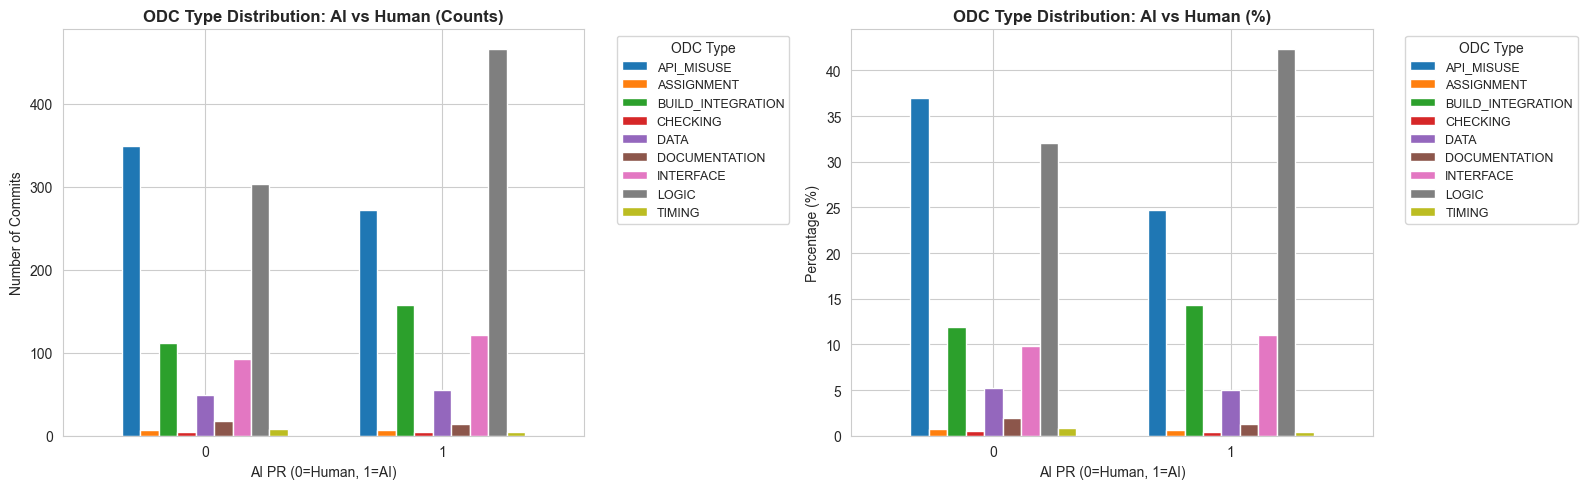

✓ Saved: rq3_odc_distribution.png


In [24]:
# Visualization 1: ODC Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By count
odc_counts = pd.crosstab(df['ai_pr'], df['odc_type_name'])
odc_counts.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('ODC Type Distribution: AI vs Human (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('AI PR (0=Human, 1=AI)')
axes[0].set_ylabel('Number of Commits')
axes[0].legend(title='ODC Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# By percentage
odc_pct = pd.crosstab(df['ai_pr'], df['odc_type_name'], normalize='index') * 100
odc_pct.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('ODC Type Distribution: AI vs Human (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('AI PR (0=Human, 1=AI)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='ODC Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/rq3_odc_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: rq3_odc_distribution.png")

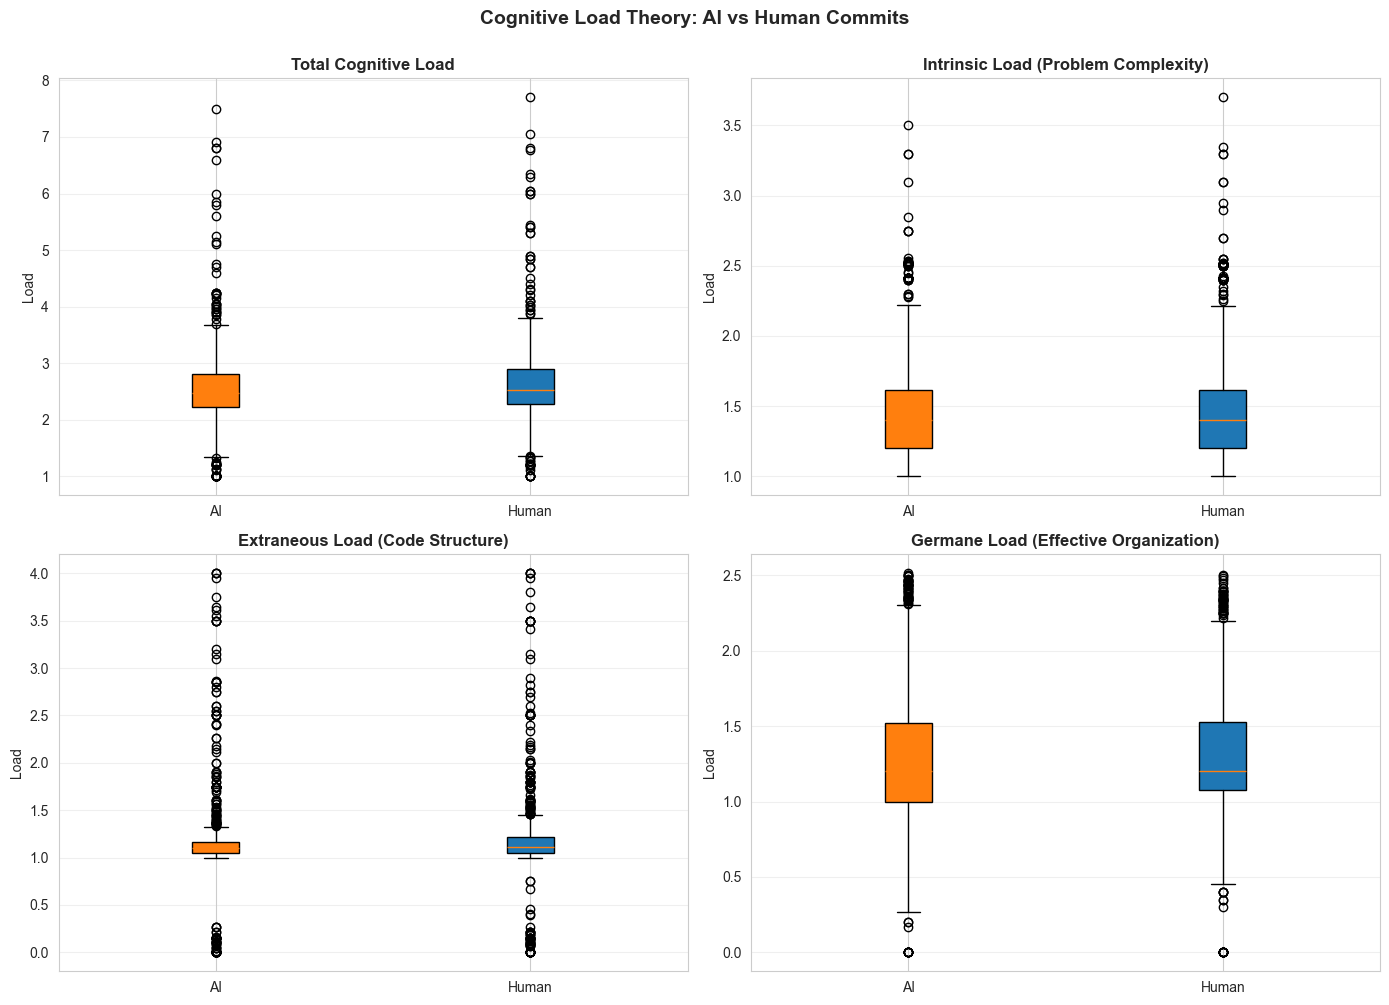

✓ Saved: rq3_cognitive_load_comparison.png


In [25]:
# Visualization 2: Cognitive Load Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total cognitive load
data_clt = [ai_clt, human_clt]
bp1 = axes[0, 0].boxplot(data_clt, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#ff7f0e', '#1f77b4']):
    patch.set_facecolor(color)
axes[0, 0].set_title('Total Cognitive Load', fontweight='bold')
axes[0, 0].set_ylabel('Load')
axes[0, 0].grid(axis='y', alpha=0.3)

# Intrinsic load
data_int = [ai_intrinsic, human_intrinsic]
bp2 = axes[0, 1].boxplot(data_int, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#ff7f0e', '#1f77b4']):
    patch.set_facecolor(color)
axes[0, 1].set_title('Intrinsic Load (Problem Complexity)', fontweight='bold')
axes[0, 1].set_ylabel('Load')
axes[0, 1].grid(axis='y', alpha=0.3)

# Extraneous load
data_ext = [ai_extraneous, human_extraneous]
bp3 = axes[1, 0].boxplot(data_ext, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp3['boxes'], ['#ff7f0e', '#1f77b4']):
    patch.set_facecolor(color)
axes[1, 0].set_title('Extraneous Load (Code Structure)', fontweight='bold')
axes[1, 0].set_ylabel('Load')
axes[1, 0].grid(axis='y', alpha=0.3)

# Germane load
data_germ = [ai_germane, human_germane]
bp4 = axes[1, 1].boxplot(data_germ, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp4['boxes'], ['#ff7f0e', '#1f77b4']):
    patch.set_facecolor(color)
axes[1, 1].set_title('Germane Load (Effective Organization)', fontweight='bold')
axes[1, 1].set_ylabel('Load')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Cognitive Load Theory: AI vs Human Commits', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/rq3_cognitive_load_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: rq3_cognitive_load_comparison.png")

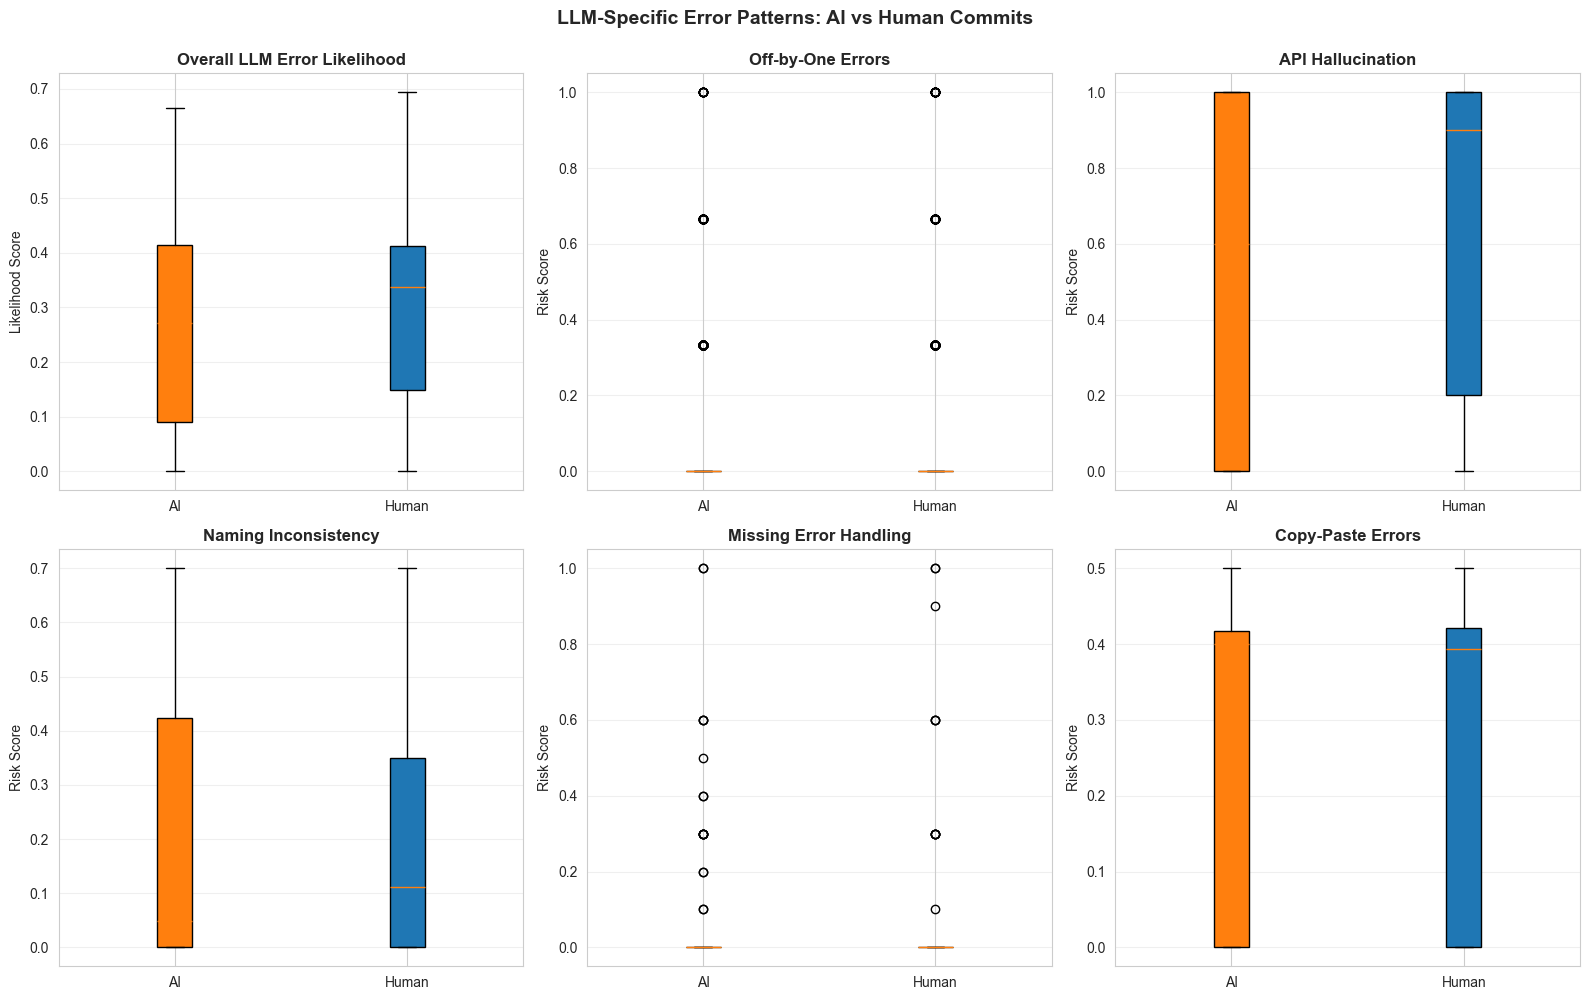

✓ Saved: rq3_llm_patterns_comparison.png


In [26]:
# Visualization 3: LLM Error Patterns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Overall LLM error likelihood
data_llm = [ai_llm, human_llm]
bp_llm = axes[0].boxplot(data_llm, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp_llm['boxes'], ['#ff7f0e', '#1f77b4']):
    patch.set_facecolor(color)
axes[0].set_title('Overall LLM Error Likelihood', fontweight='bold')
axes[0].set_ylabel('Likelihood Score')
axes[0].grid(axis='y', alpha=0.3)

# Individual patterns
patterns = [
    ('off_by_one_risk', 'Off-by-One Errors'),
    ('api_hallucination_risk', 'API Hallucination'),
    ('naming_inconsistency_risk', 'Naming Inconsistency'),
    ('missing_error_handling_risk', 'Missing Error Handling'),
    ('copy_paste_error_risk', 'Copy-Paste Errors'),
]

for idx, (col, title) in enumerate(patterns, 1):
    ai_pattern = df[df['ai_pr'] == 1][col].dropna()
    human_pattern = df[df['ai_pr'] == 0][col].dropna()
    
    bp = axes[idx].boxplot([ai_pattern, human_pattern], labels=['AI', 'Human'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#ff7f0e', '#1f77b4']):
        patch.set_facecolor(color)
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_ylabel('Risk Score')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('LLM-Specific Error Patterns: AI vs Human Commits', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/rq3_llm_patterns_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: rq3_llm_patterns_comparison.png")

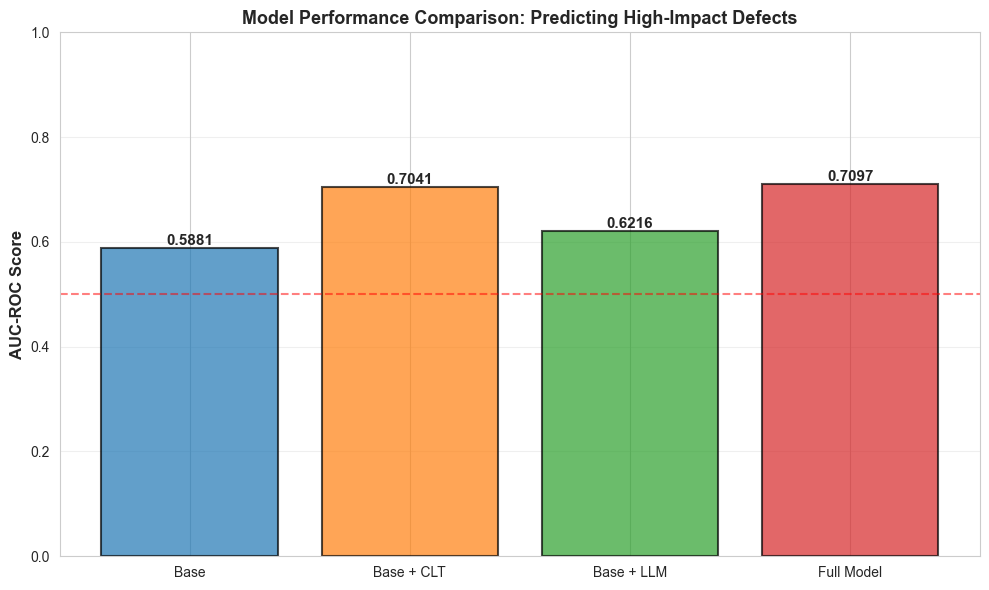

✓ Saved: rq3_model_comparison.png


In [27]:
# Visualization 4: Model Comparison - AUC Improvement
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Base', 'Base + CLT', 'Base + LLM', 'Full Model']
auc_scores = [auc_base, auc_clt, auc_llm, auc_full]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(models, auc_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, auc in zip(bars, auc_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('AUC-ROC Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Predicting High-Impact Defects', 
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Classifier')

plt.tight_layout()
plt.savefig('../results/rq3_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: rq3_model_comparison.png")

In [28]:
print("\n" + "="*90)
print("RQ3 ANALYSIS PIPELINE COMPLETE")
print("="*90)

print(f"\nData Summary:")
print(f"  Total commits analyzed: {len(df):,}")
print(f"  AI-generated: {(df['ai_pr']==1).sum():,} ({(df['ai_pr']==1).sum()/len(df)*100:.1f}%)")
print(f"  Human-generated: {(df['ai_pr']==0).sum():,} ({(df['ai_pr']==0).sum()/len(df)*100:.1f}%)")

print(f"\nODC Classification:")

def print_nunique(label, candidates):
    for col in candidates:
        if col in df.columns:
            print(f"  {label}: {df[col].nunique()}")
            return
    print(f"  {label}: N/A (column missing)")

print_nunique("Defect types identified", ["odc_type_group", "odc_type_name", "odc_type"])
print_nunique("Defect classes identified", ["odc_class_group", "odc_class_name", "odc_class"])
print_nunique("Defect triggers identified", ["odc_trigger_group", "odc_trigger_name", "odc_trigger"])
print_nunique("Impact levels identified", ["odc_impact_group", "odc_impact_name", "odc_impact"])

print(f"\nCognitive Load Theory:")
print(f"  Low load: {(df['clt_category']==0).sum():,} ({(df['clt_category']==0).sum()/len(df)*100:.1f}%)")
print(f"  Moderate load: {(df['clt_category']==1).sum():,} ({(df['clt_category']==1).sum()/len(df)*100:.1f}%)")
print(f"  High load: {(df['clt_category']==2).sum():,} ({(df['clt_category']==2).sum()/len(df)*100:.1f}%)")
print(f"  Very high load: {(df['clt_category']==3).sum():,} ({(df['clt_category']==3).sum()/len(df)*100:.1f}%)")

print(f"\nDomains Analyzed:")
domain_counts = df['domain_type_group'].value_counts().sort_index()
for domain, count in domain_counts.items():
    print(f"  {domain_names.get(domain, 'Unknown')}: {count:,}")

print(f"\n" + "="*90)
print("KEY FINDINGS:")
print(f"  ✓ H1 Chi-square: {p_val:.6f} - {'SUPPORTED' if p_val < 0.05 else 'NOT SUPPORTED'}")
print(f"  ✓ H2 Chi-square: {p_val_imp:.6f} - {'SUPPORTED' if p_val_imp < 0.05 else 'NOT SUPPORTED'}")  
print(f"  ✓ H3 LLM Patterns: {p_val_llm:.6f} - {'SUPPORTED' if p_val_llm < 0.05 else 'NOT SUPPORTED'}")
print("="*90)


RQ3 ANALYSIS PIPELINE COMPLETE

Data Summary:
  Total commits analyzed: 2,044
  AI-generated: 1,100 (53.8%)
  Human-generated: 944 (46.2%)

ODC Classification:
  Defect types identified: 9
  Defect classes identified: 3
  Defect triggers identified: 1
  Impact levels identified: 4

Cognitive Load Theory:
  Low load: 116 (5.7%)
  Moderate load: 1,869 (91.4%)
  High load: 43 (2.1%)
  Very high load: 16 (0.8%)

Domains Analyzed:
  Web Development: 507
  Data Science: 435
  Mobile Development: 44
  Systems Programming: 35
  Other: 1,023

KEY FINDINGS:
  ✓ H1 Chi-square: 0.000000 - SUPPORTED
  ✓ H2 Chi-square: 0.000000 - SUPPORTED
  ✓ H3 LLM Patterns: 0.000018 - SUPPORTED
